## Improved Prediction of Parkinson’s Disease Medication Needs Through Cascade Conformal Prediction

### AKA Two-Stage Approach with Venn-Abers Calibration + Conformal Prediction
Rationale: Building on (Diaz-Rincon et al., 2025) instead of using the predicted probability of LEDD change to filter out patients without medication changes, We use Venn Abers (VA) uncertainty in Stage 1 to inform Stage 2 Conformal Prediction (CP) intervals.

Hypothesis:
- Low uncertainty → Stage 2 provides narrow intervals (confident)
- High uncertainty → Stage 2 provides wide intervals (cautious)

This is the cascade effect: Stage 1 confidence propagates to Stage 2.

In [1]:
import pandas as pd
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from venn_abers import VennAbers

from mapie.regression import MapieRegressor
from mapie.metrics import regression_coverage_score, regression_mean_width_score
from mapie.subsample import Subsample

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve

from scipy.stats import ttest_1samp, bootstrap

import warnings
warnings.filterwarnings('ignore', message='WARNING: The predictions are ill-sorted')

In [2]:
color_azure = '#0097B2'
color_orange = '#F35000'
color_blue = '#263985' 
color_red = '#B00000'
color_yellow = '#FCD116'
color_dark_grey = '#A9A9A9'
color_purple = '#9740A6'
color_light_purple = '#AA8ED6'
color_gold = '#FFD700'
color_gold_2 = '#FFA500' 
color_palette = [color_azure, color_orange, color_blue, color_red, color_yellow, color_dark_grey, color_purple, color_light_purple, color_gold]
color_palette_2 = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#4B3F72', '#73956F']

## Data Loading and Preprocessing

In [3]:
path = 'data/data_1Y.csv'
data = pd.read_csv(path)

# Continous Outcome (LEDD Change)
normalized_pctg_change = data['normalized_percent_change']  # Save for Stage 2
data.drop(columns=['normalized_percent_change'], inplace=True)

# Prepare features
xgboost_df = data.copy()

# One-hot encoding
demographic_vars = ['gender_source_value', 'race_source_value', 'ethnicity_source_value']
xgboost_df = pd.get_dummies(xgboost_df, columns=demographic_vars)

# Scaling
scaler = MinMaxScaler()
numeric_vars = ['mean_led_per_visit', 'age', 'length_of_stay', 'days_since_last_visit', 'days_to_diagnosis']
for var in numeric_vars:
    xgboost_df[var] = scaler.fit_transform(xgboost_df[[var]])

# Reordering columns
prediction_to_last = xgboost_df.pop('prediction')
xgboost_df['prediction'] = prediction_to_last

# Features and targets
X = xgboost_df.iloc[:, :-1]
y_binary = xgboost_df.iloc[:, -1]  # Binary: medication change needed
y_continuous = normalized_pctg_change  # Continuous: percent change in LEDD

# Stage 1: Binary Classification with Venn-Abers
Get VA uncertainty estimates for ALL patients in Stage 1 binary prediction. This will inform Stage 2 interval widths instead of filtering out patients

In [4]:
print("Stage 1: Binary Classification + Venn-Abers Calibration")
random_state = 21

# Split for Stage 1: Train on 80%, use 20% for VA calibration
X_train_stage1, X_test_stage1, y_train_stage1, y_test_stage1 = train_test_split(
    X, y_binary, test_size=0.2, random_state=random_state
)

print(f"\nStage 1 Split:")
print(f"  Training (for binary):  {len(X_train_stage1):4d} ({len(X_train_stage1)/len(X)*100:.1f}%)")
print(f"  Test (for VA calib):    {len(X_test_stage1):4d} ({len(X_test_stage1)/len(X)*100:.1f}%)")

# XGBoost parameters
best_params = {
    "eval_metric": "auc",
    "objective": "binary:logistic",
    'sampling_method': 'gradient_based',
    'alpha': 0.1,
    'lambda': 1,
    'learning_rate': 0.1,
    'max_depth': 7,
    'tree_method': 'hist',
    'device': "cuda",
}
# Train XGBoost binary classifier on FULL training set
d_train = xgb.DMatrix(X_train_stage1, label=y_train_stage1)
d_test = xgb.DMatrix(X_test_stage1, label=y_test_stage1)

print("\nTraining Stage 1 XGBoost classifier...")
model_stage1 = xgb.train(
    best_params, 
    d_train,
    num_boost_round=700,
    evals=[(d_test, "validation")],
    verbose_eval=100,
    early_stopping_rounds=10
)

# Get predictions on held-out test set for VA calibration
print("\nGetting predictions for Venn-Abers calibration...")
p_test_uncalibrated = model_stage1.predict(
    d_test, 
    iteration_range=(0, model_stage1.best_iteration + 1)
)

# Convert to 2D for VennAbers
p_test_2d = np.column_stack([1 - p_test_uncalibrated, p_test_uncalibrated])

# Fit Venn-Abers calibrator
print("Calibrating with Venn-Abers...")
va = VennAbers()
va.fit(p_test_2d, y_test_stage1.values)

# Get VA predictions for ALL patients
print("\nGetting VA predictions for ALL patients...")
d_all = xgb.DMatrix(X)
p_all_uncalibrated = model_stage1.predict(
    d_all, 
    iteration_range=(0, model_stage1.best_iteration + 1)
)

# Convert to 2D and get VA intervals
p_all_2d = np.column_stack([1 - p_all_uncalibrated, p_all_uncalibrated])
p_lower_all_2d, p_upper_all_2d = va.predict_proba(p_all_2d)

# Extract predictions for class 1 (needs medication change)
p_lower_all = p_lower_all_2d[:, 1]
p_upper_all = p_upper_all_2d[:, 1]
p_mid_all = (p_lower_all + p_upper_all) / 2
va_uncertainty_all = p_upper_all - p_lower_all

print(f"\nVA predictions computed for {len(X)} patients")
print(f"VA Uncertainty Statistics (ALL patients):")
print(f"  Mean:   {va_uncertainty_all.mean():.4f}")
print(f"  Std:    {va_uncertainty_all.std():.4f}")
print(f"  Min:    {va_uncertainty_all.min():.4f}")
print(f"  Max:    {va_uncertainty_all.max():.4f}")
print(f"  Median: {np.median(va_uncertainty_all):.4f}")

Stage 1: Binary Classification + Venn-Abers Calibration

Stage 1 Split:
  Training (for binary):  4884 (80.0%)
  Test (for VA calib):    1221 (20.0%)

Training Stage 1 XGBoost classifier...
[0]	validation-auc:0.86294
[100]	validation-auc:0.95154
[200]	validation-auc:0.96313
[241]	validation-auc:0.96421

Getting predictions for Venn-Abers calibration...
Calibrating with Venn-Abers...

Getting VA predictions for ALL patients...

VA predictions computed for 6105 patients
VA Uncertainty Statistics (ALL patients):
  Mean:   0.0069
  Std:    0.0163
  Min:    0.0000
  Max:    0.1537
  Median: 0.0003


# Selection of Stage 2 patients

We do not filter by probability threshold but useonly use patients who actually need medication change (y_binary == 1)

In [5]:
print("Selecting Stage 2 patients - No probability thresholding")
# Use only patients who actually need medication change
# (This is the TRUE POSITIVE class from Stage 1)
mask = (y_binary == 1)

X_stage2 = X[mask]
y_stage2 = y_continuous[mask]
va_uncertainty_stage2 = va_uncertainty_all[mask]
p_lower_stage2 = p_lower_all[mask]
p_upper_stage2 = p_upper_all[mask]

print(f"\nSelection criterion: y_binary == 1 (actually needs medication change)")
print(f"Patients selected: {len(X_stage2)} / {len(X)} ({len(X_stage2)/len(X)*100:.1f}%)")
print(f"\nVA Uncertainty in STAGE 2 population:")
print(f"  Mean:   {va_uncertainty_stage2.mean():.4f}")
print(f"  Std:    {va_uncertainty_stage2.std():.4f}")
print(f"  Min:    {va_uncertainty_stage2.min():.4f}")
print(f"  Max:    {va_uncertainty_stage2.max():.4f}")
print(f"  Range:  {va_uncertainty_stage2.max() - va_uncertainty_stage2.min():.4f}")

# Flag high uncertainty patients (for analysis)
HIGH_UNCERTAINTY_THRESHOLD = np.percentile(va_uncertainty_stage2, 75)  # Top 25%
is_high_uncertainty = va_uncertainty_stage2 > HIGH_UNCERTAINTY_THRESHOLD

print(f"\nHigh Uncertainty Flagging:")
print(f"  Threshold (75th percentile): {HIGH_UNCERTAINTY_THRESHOLD:.4f}")
print(f"  Patients flagged as HIGH uncertainty: {is_high_uncertainty.sum()} ({is_high_uncertainty.sum()/len(X_stage2)*100:.1f}%)")
print(f"  → These will get WIDER intervals to maintain coverage")


Selecting Stage 2 patients - No probability thresholding

Selection criterion: y_binary == 1 (actually needs medication change)
Patients selected: 1533 / 6105 (25.1%)

VA Uncertainty in STAGE 2 population:
  Mean:   0.0219
  Std:    0.0256
  Min:    0.0002
  Max:    0.1537
  Range:  0.1535

High Uncertainty Flagging:
  Threshold (75th percentile): 0.0294
  Patients flagged as HIGH uncertainty: 372 (24.3%)
  → These will get WIDER intervals to maintain coverage


Stage 2 Split

In [6]:
print("Stage 2: Train/Test Split")

X_train_2, X_test_2, y_train_2, y_test_2, \
va_unc_train_2, va_unc_test_2, \
p_lower_train_2, p_lower_test_2 = train_test_split(
    X_stage2, y_stage2,
    va_uncertainty_stage2,
    p_lower_stage2,
    test_size=0.2, random_state=random_state
)

print(f"Training: {len(X_train_2)} patients")
print(f"Test:     {len(X_test_2)} patients")
print(f"Mean LEDD change (train): {y_train_2.mean():.3f}")
print(f"Mean LEDD change (test):  {y_test_2.mean():.3f}")

# Train base regression model
regression_params = {
    'alpha': 0.1,
    'lambda': 1,
    'learning_rate': 0.1,
    'max_depth': 7,
    'n_estimators': 700,
    "eval_metric": 'rmse',
    'objective': 'reg:squarederror',
    'sampling_method': 'gradient_based',
    'tree_method': 'hist',
    'device': "cuda"
}

print("\nTraining base regression model...")
xgb_model_base = xgb.XGBRegressor(**regression_params, random_state=random_state)
xgb_model_base.fit(X_train_2, y_train_2)

y_pred_base = xgb_model_base.predict(X_test_2)
rmse = np.sqrt(mean_squared_error(y_test_2, y_pred_base))
mae = mean_absolute_error(y_test_2, y_pred_base)
r2 = r2_score(y_test_2, y_pred_base)

print(f"Base Model Performance:")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  R²:   {r2:.4f}")

Stage 2: Train/Test Split
Training: 1226 patients
Test:     307 patients
Mean LEDD change (train): 0.017
Mean LEDD change (test):  0.036

Training base regression model...
Base Model Performance:
  RMSE: 0.0995
  MAE:  0.0380
  R²:   0.9801


/home/rdiazrincon/.local/lib/python3.10/site-packages/xgboost/core.py:160: UserWarning: [12:46:08] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


# Conformal Methods

In [7]:
STRATEGIES = {
    "naive": {"method": "naive"},
    "cv_plus": {"method": "plus", "cv": 10},
    "jackknife_plus_ab": {"method": "plus", "cv": Subsample(n_resamplings=50)},
}
alpha = 0.2  # Target: 80% coverage

# Experiment 1: Baseline (No VA Uncertainty)

In [8]:
print("Experiment 1: Baseline (No VA Uncertainty)")
print("Standard conformal prediction - uniform intervals for all patients")
results_baseline = {}

for strategy, params in STRATEGIES.items():
    # Standard MAPIE conformal prediction
    mapie = MapieRegressor(
        xgb_model_base, 
        test_size=0.2, 
        **params, 
        random_state=random_state
    )
    mapie.fit(X_train_2, y_train_2)
    y_pred, y_pis = mapie.predict(X_test_2, alpha=alpha)
    
    # Evaluate
    coverage = regression_coverage_score(y_test_2, y_pis[:, 0, 0], y_pis[:, 1, 0])
    width = regression_mean_width_score(y_pis[:, 0, 0], y_pis[:, 1, 0])
    
    results_baseline[strategy] = {
        'y_pred': y_pred,
        'y_pis': y_pis,
        'coverage': coverage,
        'width': width,
        'method': 'baseline'
    }
    
    print(f"  {strategy:20s}: Coverage={coverage:.4f}, Width={width:.4f}")

Experiment 1: Baseline (No VA Uncertainty)
Standard conformal prediction - uniform intervals for all patients
  naive               : Coverage=0.5244, Width=0.0306
  cv_plus             : Coverage=0.8339, Width=0.1002
  jackknife_plus_ab   : Coverage=0.6189, Width=0.1326


# Experiment 2: Stratified by VA Uncertainty (Mondrian CP)

Here we separate CP per uncertainty level e.g low, med, high based on uncertainty quantiles from the VA estimates

In [9]:
print("Stratified VA (Mondrian CP)")
# Create uncertainty bins using training set quantiles
# This ensures train and test use SAME bin boundaries
quantiles = [0, 0.33, 0.67, 1.0]
bin_edges = np.percentile(va_unc_train_2, [0, 33.33, 66.67, 100])

print(f"\nBin Definitions (from training set):")
print(f"  LOW:    [{bin_edges[0]:.4f}, {bin_edges[1]:.4f})")
print(f"  MEDIUM: [{bin_edges[1]:.4f}, {bin_edges[2]:.4f})")
print(f"  HIGH:   [{bin_edges[2]:.4f}, {bin_edges[3]:.4f}]")

# Apply same bins to both train and test
bins_train = pd.cut(va_unc_train_2, bins=bin_edges, labels=['low', 'medium', 'high'], 
                   include_lowest=True, duplicates='drop')
bins_test = pd.cut(va_unc_test_2, bins=bin_edges, labels=['low', 'medium', 'high'], 
                  include_lowest=True, duplicates='drop')

print(f"\nBin Distribution:")
print("  Training:")
for cat in ['low', 'medium', 'high']:
    n = (bins_train == cat).sum()
    unc = va_unc_train_2[bins_train == cat]
    if len(unc) > 0:
        print(f"    {cat:8s}: {n:4d} patients, uncertainty [{unc.min():.4f}, {unc.max():.4f}]")
print("  Test:")
for cat in ['low', 'medium', 'high']:
    n = (bins_test == cat).sum()
    unc = va_unc_test_2[bins_test == cat]
    if len(unc) > 0:
        print(f"    {cat:8s}: {n:4d} patients, uncertainty [{unc.min():.4f}, {unc.max():.4f}]")

results_stratified = {}

for strategy, params in STRATEGIES.items():
    print(f"\n  Running Stratified {strategy}...")
    
    # Initialize arrays for full test set
    y_pred_all = np.zeros(len(X_test_2))
    y_lower_all = np.zeros(len(X_test_2))
    y_upper_all = np.zeros(len(X_test_2))
    
    results_by_bin = {}
    
    # Process each uncertainty bin separately
    for category in ['low', 'medium', 'high']:
        mask_train = (bins_train == category)
        mask_test = (bins_test == category)
        
        n_train_cat = mask_train.sum()
        n_test_cat = mask_test.sum()
        
        # Check if we have enough data
        if n_train_cat < 10 or n_test_cat < 2:
            print(f"    {category:8s}: SKIPPED (insufficient data)")
            continue
        
        print(f"    {category:8s}: Training on {n_train_cat} samples...")
        
        # Get data for this bin
        X_train_cat = X_train_2[mask_train]
        y_train_cat = y_train_2[mask_train]
        X_test_cat = X_test_2[mask_test]
        y_test_cat = y_test_2[mask_test]
        
        # Train model for this bin
        model_cat = xgb.XGBRegressor(**regression_params, random_state=random_state)
        model_cat.fit(X_train_cat, y_train_cat)
        
        # Conformal prediction for this bin
        mapie_cat = MapieRegressor(
            model_cat, 
            test_size=0.2, 
            **params, 
            random_state=random_state
        )
        mapie_cat.fit(X_train_cat, y_train_cat)
        y_pred_cat, y_pis_cat = mapie_cat.predict(X_test_cat, alpha=alpha)
        
        # Store results for this bin
        y_pred_all[mask_test] = y_pred_cat
        y_lower_all[mask_test] = y_pis_cat[:, 0, 0]
        y_upper_all[mask_test] = y_pis_cat[:, 1, 0]
        
        # Per-bin metrics
        cov_cat = regression_coverage_score(
            y_test_cat, y_pis_cat[:, 0, 0], y_pis_cat[:, 1, 0]
        )
        width_cat = regression_mean_width_score(
            y_pis_cat[:, 0, 0], y_pis_cat[:, 1, 0]
        )
        
        results_by_bin[category] = {
            'coverage': cov_cat,
            'width': width_cat,
            'n_test': n_test_cat,
            'n_train': n_train_cat
        }
        
        print(f"              Coverage={cov_cat:.4f}, Width={width_cat:.4f}")
    
    # Overall metrics
    coverage = np.mean((y_test_2 >= y_lower_all) & (y_test_2 <= y_upper_all))
    width = np.mean(y_upper_all - y_lower_all)
    
    results_stratified[strategy] = {
        'y_pred': y_pred_all,
        'y_lower': y_lower_all,
        'y_upper': y_upper_all,
        'coverage': coverage,
        'width': width,
        'results_by_bin': results_by_bin,
        'method': 'stratified'
    }
    
    print(f"    OVERALL:   Coverage={coverage:.4f}, Width={width:.4f}")

Stratified VA (Mondrian CP)

Bin Definitions (from training set):
  LOW:    [0.0002, 0.0077)
  MEDIUM: [0.0077, 0.0189)
  HIGH:   [0.0189, 0.1537]

Bin Distribution:
  Training:
    low     :  445 patients, uncertainty [0.0002, 0.0077]
    medium  :  375 patients, uncertainty [0.0077, 0.0189]
    high    :  406 patients, uncertainty [0.0192, 0.1537]
  Test:
    low     :  122 patients, uncertainty [0.0002, 0.0077]
    medium  :   89 patients, uncertainty [0.0077, 0.0189]
    high    :   96 patients, uncertainty [0.0196, 0.1349]

  Running Stratified naive...
    low     : Training on 445 samples...
              Coverage=0.5820, Width=0.0312
    medium  : Training on 375 samples...
              Coverage=0.6067, Width=0.0191
    high    : Training on 406 samples...
              Coverage=0.6354, Width=0.0281
    OVERALL:   Coverage=0.6059, Width=0.0267

  Running Stratified cv_plus...
    low     : Training on 445 samples...
              Coverage=0.8279, Width=0.0945
    medium  : Tra

Weighted (Cascade) Conformal Prediciton. We weight calibration by VA uncertainty using a linear weight $w = 1 + 2*u$

In [10]:
results_weighted = {}

for strategy, params in STRATEGIES.items():
    print(f"\n  Running Weighted {strategy}...")
    
    # Get training predictions and residuals
    y_pred_train = xgb_model_base.predict(X_train_2)
    residuals_train = np.abs(np.asarray(y_train_2) - y_pred_train)
    
    # Apply linear weighting
    va_unc_train_array = np.asarray(va_unc_train_2)
    weights = 1 + 2.0 * va_unc_train_array
    
    print(f"    Weights: [{weights.min():.3f}, {weights.max():.3f}], "
          f"Mean={weights.mean():.3f}, Std={weights.std():.3f}")
    
    # Weight residuals
    weighted_residuals = residuals_train * weights
    
    # Compute conformity score
    quantile_level = (1 - alpha) * 100
    sorted_indices = np.argsort(weighted_residuals)
    sorted_residuals = weighted_residuals[sorted_indices]
    conformity_score = np.percentile(sorted_residuals, quantile_level)
    
    print(f"    Conformity score: {conformity_score:.4f}")
    
    # Apply to test set
    y_pred_test = xgb_model_base.predict(X_test_2)
    va_unc_test_array = np.asarray(va_unc_test_2)
    test_weights = 1 + 2.0 * va_unc_test_array
    
    # Prediction intervals
    y_lower = y_pred_test - conformity_score * test_weights
    y_upper = y_pred_test + conformity_score * test_weights
    
    # Clip to reasonable range
    y_lower = np.clip(y_lower, -3, 3)
    y_upper = np.clip(y_upper, -3, 3)
    
    # Evaluate
    y_test_2_array = np.asarray(y_test_2)
    coverage = np.mean((y_test_2_array >= y_lower) & (y_test_2_array <= y_upper))
    width = np.mean(y_upper - y_lower)
    
    results_weighted[strategy] = {
        'y_pred': y_pred_test,
        'y_lower': y_lower,
        'y_upper': y_upper,
        'coverage': coverage,
        'width': width,
        'method': 'weighted'
    }
    
    print(f"    Coverage={coverage:.4f}, Width={width:.4f}")




  Running Weighted naive...
    Weights: [1.000, 1.307], Mean=1.044, Std=0.051
    Conformity score: 0.0158
    Coverage=0.5505, Width=0.0330

  Running Weighted cv_plus...
    Weights: [1.000, 1.307], Mean=1.044, Std=0.051
    Conformity score: 0.0158
    Coverage=0.5505, Width=0.0330

  Running Weighted jackknife_plus_ab...
    Weights: [1.000, 1.307], Mean=1.044, Std=0.051
    Conformity score: 0.0158
    Coverage=0.5505, Width=0.0330


Comprehensive Comparison

In [11]:
for conf_method in ["naive", "cv_plus", "jackknife_plus_ab"]:
    print(f"\n{conf_method.upper()}")
    print("-" * 80)
    
    # Baseline
    base = results_baseline[conf_method]
    print(f"  Baseline (Ignores VA):    Cov={base['coverage']:.4f}, Width={base['width']:.4f}")
    
    # Stratified
    strat = results_stratified[conf_method]
    print(f"  Stratified (Uses VA):     Cov={strat['coverage']:.4f}, Width={strat['width']:.4f}")
    
    if 'results_by_bin' in strat:
        for bin_name in ['low', 'medium', 'high']:
            if bin_name in strat['results_by_bin']:
                bin_res = strat['results_by_bin'][bin_name]
                print(f"    {bin_name:8s}: Cov={bin_res['coverage']:.4f}, Width={bin_res['width']:.4f}")
    
    # Weighted
    wtd = results_weighted[conf_method]
    print(f"  Weighted (Continuous VA): Cov={wtd['coverage']:.4f}, Width={wtd['width']:.4f}")
    
    print()


NAIVE
--------------------------------------------------------------------------------
  Baseline (Ignores VA):    Cov=0.5244, Width=0.0306
  Stratified (Uses VA):     Cov=0.6059, Width=0.0267
    low     : Cov=0.5820, Width=0.0312
    medium  : Cov=0.6067, Width=0.0191
    high    : Cov=0.6354, Width=0.0281
  Weighted (Continuous VA): Cov=0.5505, Width=0.0330


CV_PLUS
--------------------------------------------------------------------------------
  Baseline (Ignores VA):    Cov=0.8339, Width=0.1002
  Stratified (Uses VA):     Cov=0.8697, Width=0.1240
    low     : Cov=0.8279, Width=0.0945
    medium  : Cov=0.8539, Width=0.1061
    high    : Cov=0.9375, Width=0.1782
  Weighted (Continuous VA): Cov=0.5505, Width=0.0330


JACKKNIFE_PLUS_AB
--------------------------------------------------------------------------------
  Baseline (Ignores VA):    Cov=0.6189, Width=0.1326
  Stratified (Uses VA):     Cov=0.6840, Width=0.1686
    low     : Cov=0.6230, Width=0.1371
    medium  : Cov=0.674

Analysis of Cascade Uncertainty (Wighted CP)

In [12]:
print("How Stage 1 VA Uncertainty Propagates to Stage 2 Intervals:")
for conf_method in ["naive", "cv_plus", "jackknife_plus_ab"]:
    if 'results_by_bin' not in results_stratified[conf_method]:
        continue
        
    print(f"\n{conf_method.upper()}:")
    
    for bin_name in ['low', 'medium', 'high']:
        if bin_name not in results_stratified[conf_method]['results_by_bin']:
            continue
            
        bin_res = results_stratified[conf_method]['results_by_bin'][bin_name]
        mask = (bins_test == bin_name)
        unc_range = va_unc_test_2[mask]
        
        print(f"  {bin_name.upper():8s} Stage 1 Uncertainty [{unc_range.min():.4f}, {unc_range.max():.4f}]")
        print(f"    → Stage 2 Width:    {bin_res['width']:.4f}")
        print(f"    → Coverage:         {bin_res['coverage']:.4f}")
        print(f"    → N samples:       {bin_res['n_test']}")

How Stage 1 VA Uncertainty Propagates to Stage 2 Intervals:

NAIVE:
  LOW      Stage 1 Uncertainty [0.0002, 0.0077]
    → Stage 2 Width:    0.0312
    → Coverage:         0.5820
    → N samples:       122
  MEDIUM   Stage 1 Uncertainty [0.0077, 0.0189]
    → Stage 2 Width:    0.0191
    → Coverage:         0.6067
    → N samples:       89
  HIGH     Stage 1 Uncertainty [0.0196, 0.1349]
    → Stage 2 Width:    0.0281
    → Coverage:         0.6354
    → N samples:       96

CV_PLUS:
  LOW      Stage 1 Uncertainty [0.0002, 0.0077]
    → Stage 2 Width:    0.0945
    → Coverage:         0.8279
    → N samples:       122
  MEDIUM   Stage 1 Uncertainty [0.0077, 0.0189]
    → Stage 2 Width:    0.1061
    → Coverage:         0.8539
    → N samples:       89
  HIGH     Stage 1 Uncertainty [0.0196, 0.1349]
    → Stage 2 Width:    0.1782
    → Coverage:         0.9375
    → N samples:       96

JACKKNIFE_PLUS_AB:
  LOW      Stage 1 Uncertainty [0.0002, 0.0077]
    → Stage 2 Width:    0.1371
    →

How do High vs Low uncertainty patients perform

In [13]:
conf_method = 'cv_plus'

# Compare LOW vs HIGH directly from stratified results
if 'low' in results_stratified[conf_method]['results_by_bin'] and \
   'high' in results_stratified[conf_method]['results_by_bin']:
    
    low_res = results_stratified[conf_method]['results_by_bin']['low']
    high_res = results_stratified[conf_method]['results_by_bin']['high']
    
    print(f"\n{conf_method.upper()} Results:")
    print(f"  LOW Uncertainty Patients:")
    print(f"    N: {low_res['n_test']}")
    print(f"    Width: {low_res['width']:.4f}")
    print(f"    Coverage: {low_res['coverage']:.4f}")
    
    print(f"\n  HIGH Uncertainty Patients:")
    print(f"    N: {high_res['n_test']}")
    print(f"    Width: {high_res['width']:.4f} ({(high_res['width']/low_res['width']):.2f}× wider)")
    print(f"    Coverage: {high_res['coverage']:.4f}")
    
    print(f"\n  KEY INSIGHT:")
    if high_res['width'] > low_res['width']:
        print(f"    ✓ CASCADE WORKING: HIGH uncertainty → {(high_res['width']/low_res['width']):.2f}× wider intervals")
        print(f"    ✓ This maintains coverage ({high_res['coverage']:.1%}) for uncertain cases")
    else:
        print(f"    UNEXPECTED: HIGH uncertainty has narrower intervals")


CV_PLUS Results:
  LOW Uncertainty Patients:
    N: 122
    Width: 0.0945
    Coverage: 0.8279

  HIGH Uncertainty Patients:
    N: 96
    Width: 0.1782 (1.89× wider)
    Coverage: 0.9375

  KEY INSIGHT:
    ✓ CASCADE WORKING: HIGH uncertainty → 1.89× wider intervals
    ✓ This maintains coverage (93.8%) for uncertain cases


Plots

[]

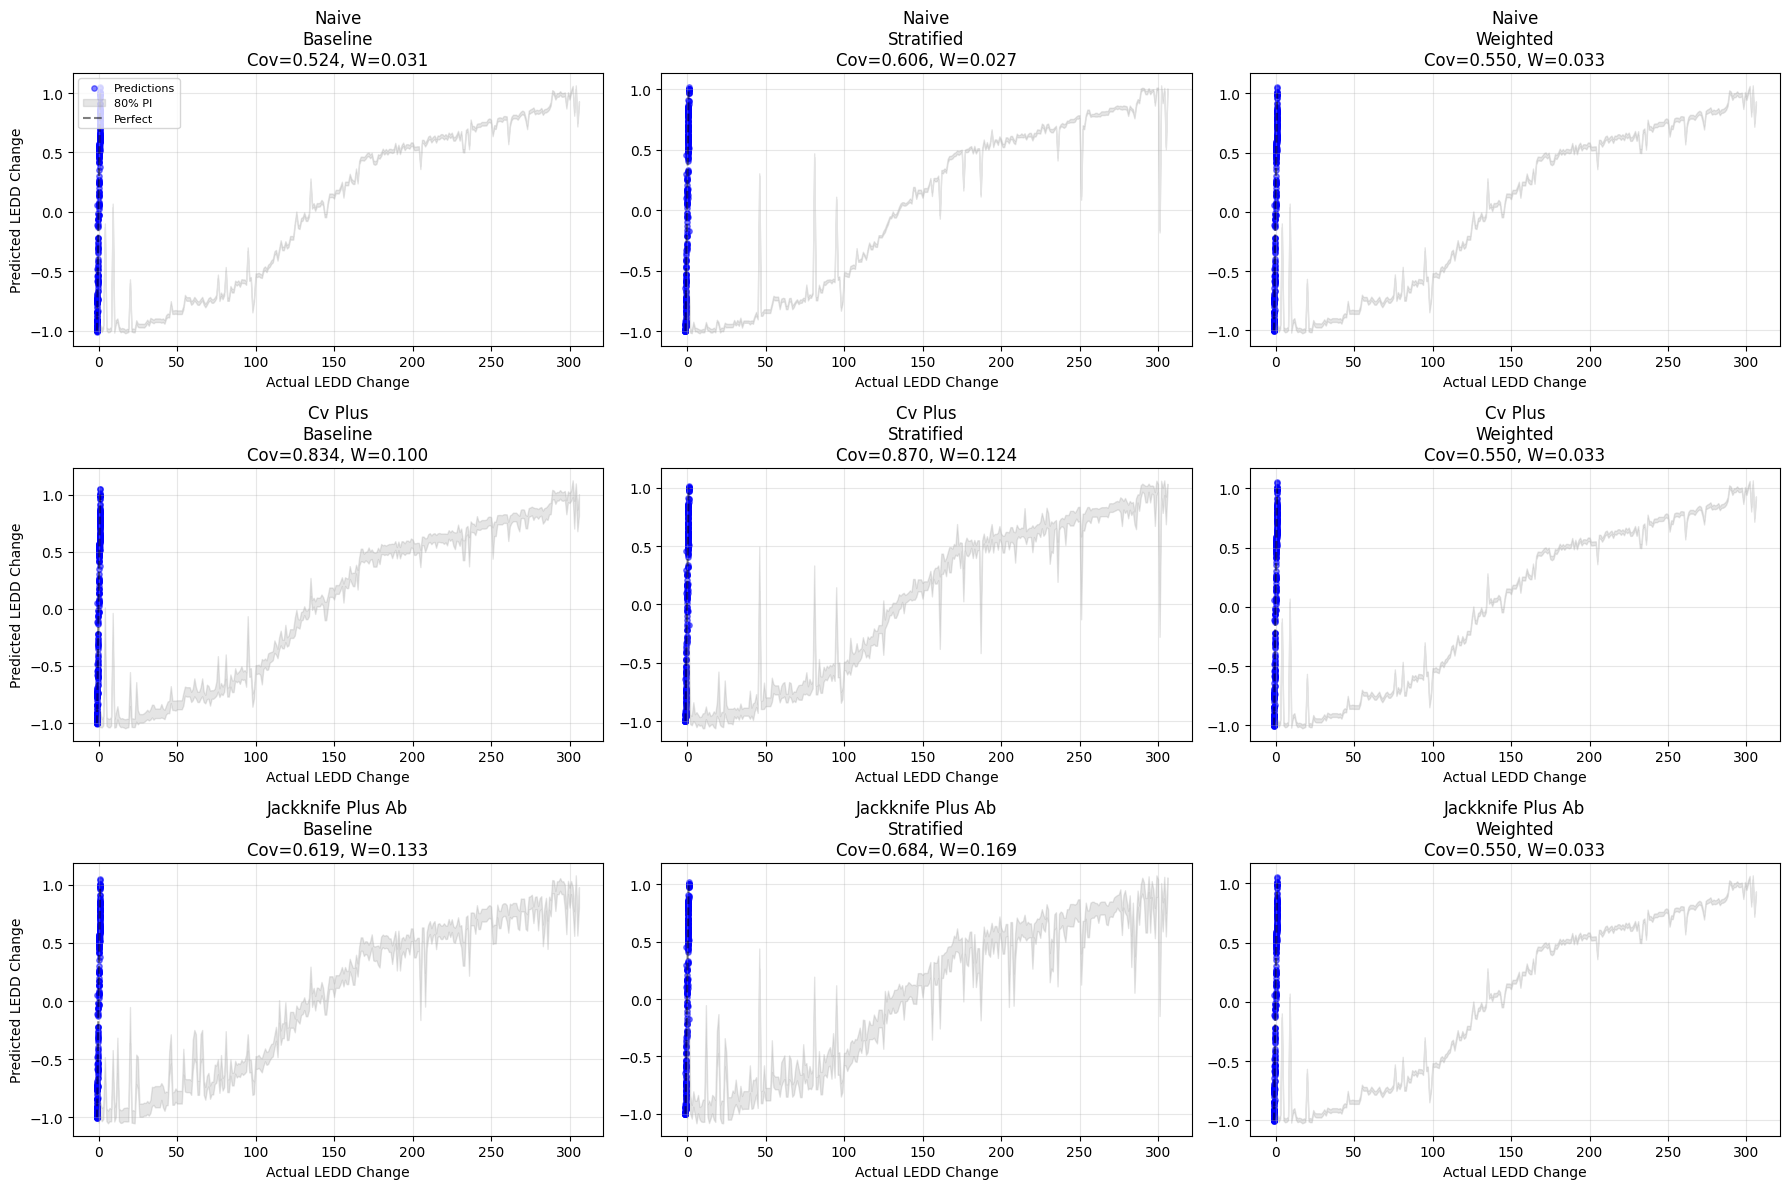

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

conf_methods = ["naive", "cv_plus", "jackknife_plus_ab"]
approaches = [
    ('Baseline', results_baseline),
    ('Stratified', results_stratified),
    ('Weighted', results_weighted)
]

for i, conf_method in enumerate(conf_methods):
    for j, (approach_name, results) in enumerate(approaches):
        ax = axes[i, j]
        
        res = results[conf_method]
        y_test = y_test_2
        y_pred = res['y_pred']
        
        if 'y_pis' in res:
            y_lower = res['y_pis'][:, 0, 0]
            y_upper = res['y_pis'][:, 1, 0]
        else:
            y_lower = res['y_lower']
            y_upper = res['y_upper']
        
        # Sort for visualization
        sort_idx = np.argsort(y_test)
        y_test_sorted = y_test.values[sort_idx] if hasattr(y_test, 'values') else y_test[sort_idx]
        y_pred_sorted = y_pred[sort_idx]
        y_lower_sorted = y_lower[sort_idx]
        y_upper_sorted = y_upper[sort_idx]
        
        # Plot
        ax.scatter(y_test_sorted, y_pred_sorted, alpha=0.5, s=15, color='blue', label='Predictions')
        ax.fill_between(range(len(y_test_sorted)), y_lower_sorted, y_upper_sorted,
                         alpha=0.2, color='gray', label='80% PI')
        ax.plot([y_test_sorted.min(), y_test_sorted.max()],
                [y_test_sorted.min(), y_test_sorted.max()], 'k--', alpha=0.5, label='Perfect')
        
        ax.set_title(f'{conf_method.replace("_", " ").title()}\n{approach_name}\n'
                    f'Cov={res["coverage"]:.3f}, W={res["width"]:.3f}')
        ax.set_xlabel('Actual LEDD Change')
        if j == 0:
            ax.set_ylabel('Predicted LEDD Change')
        ax.grid(True, alpha=0.3)
        if i == 0 and j == 0:
            ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.plot()
# plt.savefig('cascade_uncertainty_NO_PROB_FILTER.png', dpi=300, bbox_inches='tight')

Cascade Effect by bins


Key Results:
  Total samples in Stage 2: 1533
  VA uncertainty range: [0.0002, 0.1537]
  HIGH uncertainty samples: 372 (flagged, not excluded)


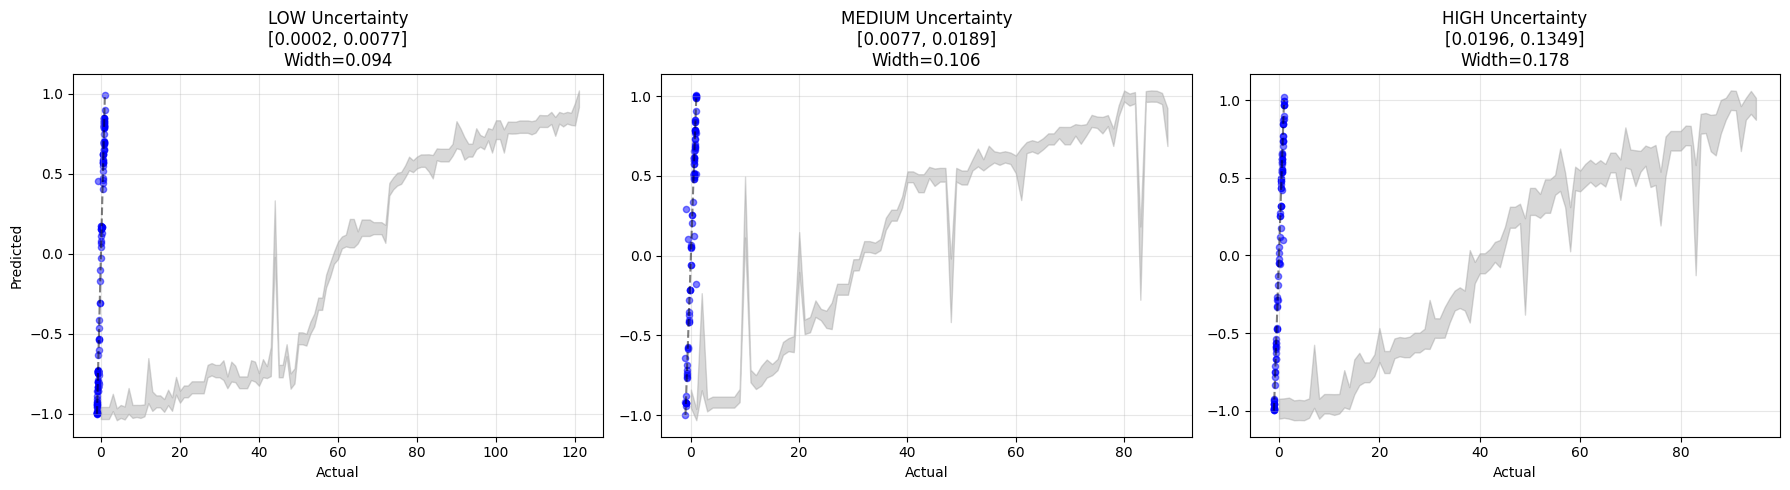

In [15]:
if 'results_by_bin' in results_stratified['cv_plus']:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, bin_name in enumerate(['low', 'medium', 'high']):
        if bin_name not in results_stratified['cv_plus']['results_by_bin']:
            continue
            
        ax = axes[idx]
        
        # Get data for this bin
        mask = (bins_test == bin_name)
        y_test_bin = y_test_2[mask]
        y_pred_bin = results_stratified['cv_plus']['y_pred'][mask]
        y_lower_bin = results_stratified['cv_plus']['y_lower'][mask]
        y_upper_bin = results_stratified['cv_plus']['y_upper'][mask]
        
        # Sort
        sort_idx = np.argsort(y_test_bin)
        y_test_sorted = y_test_bin.values[sort_idx] if hasattr(y_test_bin, 'values') else y_test_bin[sort_idx]
        y_pred_sorted = y_pred_bin[sort_idx]
        y_lower_sorted = y_lower_bin[sort_idx]
        y_upper_sorted = y_upper_bin[sort_idx]
        
        # Plot
        ax.scatter(y_test_sorted, y_pred_sorted, alpha=0.5, s=20, color='blue')
        ax.fill_between(range(len(y_test_sorted)), y_lower_sorted, y_upper_sorted,
                         alpha=0.3, color='gray')
        ax.plot([y_test_sorted.min(), y_test_sorted.max()],
                [y_test_sorted.min(), y_test_sorted.max()], 'k--', alpha=0.5)
        
        bin_res = results_stratified['cv_plus']['results_by_bin'][bin_name]
        unc_range = va_unc_test_2[mask]
        
        ax.set_title(f'{bin_name.upper()} Uncertainty\n'
                    f'[{unc_range.min():.4f}, {unc_range.max():.4f}]\n'
                    f'Width={bin_res["width"]:.3f}')
        ax.set_xlabel('Actual')
        if idx == 0:
            ax.set_ylabel('Predicted')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.plot()
    # plt.savefig('cascade_effect_by_uncertainty_bin.png', dpi=300, bbox_inches='tight')
    # print("Saved: cascade_effect_by_uncertainty_bin.png")
    # plt.close()

print("\nKey Results:")
print(f"  Total samples in Stage 2: {len(X_stage2)}")
print(f"  VA uncertainty range: [{va_uncertainty_stage2.min():.4f}, {va_uncertainty_stage2.max():.4f}]")
print(f"  HIGH uncertainty samples: {is_high_uncertainty.sum()} (flagged, not excluded)")

# Statistical Comparison
We compare both Baseline (Standard CP) and Two-Stage with the Stratified and Weighted approaches.
For each: Mean, 95% Bootstrap CI, Absolute/Relative Change, t-test, Cohen's d

In [16]:
# Baseline and Two-Stage from Table 7 (1Y)
methods = ['naive', 'cv_plus', 'jackknife_plus_ab']
method_names = {'naive': 'Naive', 'cv_plus': 'CV+', 'jackknife_plus_ab': 'J+aB'}

baseline_1y = {
    'naive': {'coverage': 0.733, 'width': 0.322},
    'cv_plus': {'coverage': 0.811, 'width': 0.460},
    'jackknife_plus_ab': {'coverage': 0.750, 'width': 0.375}
}

twostage_1y = {
    'naive': {'coverage': 0.578, 'width': 0.041},
    'cv_plus': {'coverage': 0.800, 'width': 0.082},
    'jackknife_plus_ab': {'coverage': 0.689, 'width': 0.122}
}

stratified = {
    'naive': {'coverage': results_stratified['naive']['coverage'], 'width': results_stratified['naive']['width']},
    'cv_plus': {'coverage': results_stratified['cv_plus']['coverage'], 'width': results_stratified['cv_plus']['width']},
    'jackknife_plus_ab': {'coverage': results_stratified['jackknife_plus_ab']['coverage'], 'width': results_stratified['jackknife_plus_ab']['width']}
}

weighted = {
    'naive': {'coverage': results_weighted['naive']['coverage'], 'width': results_weighted['naive']['width']},
    'cv_plus': {'coverage': results_weighted['cv_plus']['coverage'], 'width': results_weighted['cv_plus']['width']},
    'jackknife_plus_ab': {'coverage': results_weighted['jackknife_plus_ab']['coverage'], 'width': results_weighted['jackknife_plus_ab']['width']}
}

Helper functions

In [17]:
def bootstrap_ci(data, n_resamples=10000, confidence_level=0.95):
    """Compute bootstrap confidence interval"""
    res = bootstrap((data,), np.mean, n_resamples=n_resamples,
                    confidence_level=confidence_level, method='percentile',
                    random_state=42)
    return res.confidence_interval.low, res.confidence_interval.high

def format_pvalue(p):
    """Format p-value for display"""
    if p < 0.001:
        return '<0.001', '***'
    elif p < 0.01:
        return f'{p:.3f}', '**'
    elif p < 0.05:
        return f'{p:.3f}', '*'
    else:
        return f'{p:.3f}', 'ns'

def cohens_d(sample, population_mean):
    """Compute Cohen's d effect size for one-sample t-test"""
    return (np.mean(sample) - population_mean) / np.std(sample, ddof=1)

def interpret_cohens_d(d):
    """Interpret Cohen's d magnitude"""
    d_abs = abs(d)
    if d_abs < 0.2:
        return 'negligible'
    elif d_abs < 0.5:
        return 'small'
    elif d_abs < 0.8:
        return 'medium'
    else:
        return 'large'

Computing Per-Patient Coverage from Prediction Intervals

In [18]:
stratified = {}
weighted = {}

for method in methods:
    # STRATIFIED
    y_lower = results_stratified[method]['y_lower']
    y_upper = results_stratified[method]['y_upper']
    coverage_array = ((y_test_2 >= y_lower) & (y_test_2 <= y_upper)).astype(int)
    width_array = y_upper - y_lower
    
    stratified[method] = {
        'coverage': coverage_array,
        'width': width_array
    }
    
    # WEIGHTED
    y_lower = results_weighted[method]['y_lower']
    y_upper = results_weighted[method]['y_upper']
    coverage_array = ((y_test_2 >= y_lower) & (y_test_2 <= y_upper)).astype(int)
    width_array = y_upper - y_lower
    
    weighted[method] = {
        'coverage': coverage_array,
        'width': width_array
    }

Summary Statistics with Bootstrap CIs

In [19]:
summary_data = []

for method in methods:
    # Baseline
    summary_data.append({
        'Method': method_names[method],
        'Approach': 'Baseline',
        'Metric': 'Coverage',
        'Mean': f"{baseline_1y[method]['coverage']:.3f}",
        'CI': 'N/A (aggregate)'
    })
    summary_data.append({
        'Method': method_names[method],
        'Approach': 'Baseline',
        'Metric': 'Width',
        'Mean': f"{baseline_1y[method]['width']:.3f}",
        'CI': 'N/A (aggregate)'
    })
    
    # Two-Stage
    summary_data.append({
        'Method': method_names[method],
        'Approach': 'Two-Stage',
        'Metric': 'Coverage',
        'Mean': f"{twostage_1y[method]['coverage']:.3f}",
        'CI': 'N/A (aggregate)'
    })
    summary_data.append({
        'Method': method_names[method],
        'Approach': 'Two-Stage',
        'Metric': 'Width',
        'Mean': f"{twostage_1y[method]['width']:.3f}",
        'CI': 'N/A (aggregate)'
    })
    
    # CASCADE Stratified
    cov = stratified[method]['coverage']
    width = stratified[method]['width']
    
    mean_cov = np.mean(cov)
    ci_cov = bootstrap_ci(cov)
    summary_data.append({
        'Method': method_names[method],
        'Approach': 'CASCADE-Stratified',
        'Metric': 'Coverage',
        'Mean': f'{mean_cov:.3f}',
        'CI': f'[{ci_cov[0]:.3f}, {ci_cov[1]:.3f}]'
    })
    
    mean_width = np.mean(width)
    ci_width = bootstrap_ci(width)
    summary_data.append({
        'Method': method_names[method],
        'Approach': 'CASCADE-Stratified',
        'Metric': 'Width',
        'Mean': f'{mean_width:.3f}',
        'CI': f'[{ci_width[0]:.3f}, {ci_width[1]:.3f}]'
    })

df_summary = pd.DataFrame(summary_data)
display(df_summary)

,Method,Approach,Metric,Mean,CI
0,Naive,Baseline,Coverage,0.733,N/A (aggregate)
1,Naive,Baseline,Width,0.322,N/A (aggregate)
2,Naive,Two-Stage,Coverage,0.578,N/A (aggregate)
3,Naive,Two-Stage,Width,0.041,N/A (aggregate)
4,Naive,CASCADE-Stratified,Coverage,0.606,"[0.550, 0.661]"
5,Naive,CASCADE-Stratified,Width,0.027,"[0.026, 0.027]"
6,CV+,Baseline,Coverage,0.811,N/A (aggregate)
7,CV+,Baseline,Width,0.460,N/A (aggregate)
8,CV+,Two-Stage,Coverage,0.800,N/A (aggregate)
9,CV+,Two-Stage,Width,0.082,N/A (aggregate)


Statistical Significance Tests

In [20]:
test_data = []

for method in methods:
    cov_s = stratified[method]['coverage']
    width_s = stratified[method]['width']
    
    # vs Baseline - Coverage
    baseline_cov = baseline_1y[method]['coverage']
    t, p = ttest_1samp(cov_s, baseline_cov)
    p_str, sig = format_pvalue(p)
    d = cohens_d(cov_s, baseline_cov)
    d_interp = interpret_cohens_d(d)
    ci_cov = bootstrap_ci(cov_s)
    
    test_data.append({
        'Method': method_names[method],
        'Comparison': 'Baseline vs Stratified',
        'Metric': 'Coverage',
        'Reference': f"{baseline_cov:.3f}",
        'CASCADE': f"{np.mean(cov_s):.3f}",
        'CASCADE 95% CI': f"[{ci_cov[0]:.3f}, {ci_cov[1]:.3f}]",
        'Diff': f"{np.mean(cov_s) - baseline_cov:+.3f}",
        't': f'{t:.3f}',
        'p': p_str,
        'Sig': sig,
        "Cohen's d": f'{d:.3f}',
        'Effect': d_interp
    })
    
    # vs Baseline - Width
    baseline_width = baseline_1y[method]['width']
    t, p = ttest_1samp(width_s, baseline_width)
    p_str, sig = format_pvalue(p)
    d = cohens_d(width_s, baseline_width)
    d_interp = interpret_cohens_d(d)
    ci_width = bootstrap_ci(width_s)
    
    test_data.append({
        'Method': method_names[method],
        'Comparison': 'Baseline vs Stratified',
        'Metric': 'Width',
        'Reference': f"{baseline_width:.3f}",
        'CASCADE': f"{np.mean(width_s):.3f}",
        'CASCADE 95% CI': f"[{ci_width[0]:.3f}, {ci_width[1]:.3f}]",
        'Diff': f"{np.mean(width_s) - baseline_width:+.3f}",
        't': f'{t:.3f}',
        'p': p_str,
        'Sig': sig,
        "Cohen's d": f'{d:.3f}',
        'Effect': d_interp
    })
    
    # vs Two-Stage - Coverage
    twostage_cov = twostage_1y[method]['coverage']
    t, p = ttest_1samp(cov_s, twostage_cov)
    p_str, sig = format_pvalue(p)
    d = cohens_d(cov_s, twostage_cov)
    d_interp = interpret_cohens_d(d)
    ci_cov = bootstrap_ci(cov_s)
    
    test_data.append({
        'Method': method_names[method],
        'Comparison': 'Two-Stage vs Stratified',
        'Metric': 'Coverage',
        'Reference': f"{twostage_cov:.3f}",
        'CASCADE': f"{np.mean(cov_s):.3f}",
        'CASCADE 95% CI': f"[{ci_cov[0]:.3f}, {ci_cov[1]:.3f}]",
        'Diff': f"{np.mean(cov_s) - twostage_cov:+.3f}",
        't': f'{t:.3f}',
        'p': p_str,
        'Sig': sig,
        "Cohen's d": f'{d:.3f}',
        'Effect': d_interp
    })
    
    # vs Two-Stage - Width
    twostage_width = twostage_1y[method]['width']
    t, p = ttest_1samp(width_s, twostage_width)
    p_str, sig = format_pvalue(p)
    d = cohens_d(width_s, twostage_width)
    d_interp = interpret_cohens_d(d)
    ci_width = bootstrap_ci(width_s)
    
    test_data.append({
        'Method': method_names[method],
        'Comparison': 'Two-Stage vs Stratified',
        'Metric': 'Width',
        'Reference': f"{twostage_width:.3f}",
        'CASCADE': f"{np.mean(width_s):.3f}",
        'CASCADE 95% CI': f"[{ci_width[0]:.3f}, {ci_width[1]:.3f}]",
        'Diff': f"{np.mean(width_s) - twostage_width:+.3f}",
        't': f'{t:.3f}',
        'p': p_str,
        'Sig': sig,
        "Cohen's d": f'{d:.3f}',
        'Effect': d_interp
    })

df_tests = pd.DataFrame(test_data)
display(df_tests)

,Method,Comparison,Metric,Reference,CASCADE,CASCADE 95% CI,Diff,t,p,Sig,Cohen's d,Effect
0,Naive,Baseline vs Stratified,Coverage,0.733,0.606,"[0.550, 0.661]",-0.127,-4.551,<0.001,***,-0.260,small
1,Naive,Baseline vs Stratified,Width,0.322,0.027,"[0.026, 0.027]",-0.295,-1029.572,<0.001,***,-58.761,large
2,Naive,Two-Stage vs Stratified,Coverage,0.578,0.606,"[0.550, 0.661]",+0.028,0.997,0.319,ns,0.057,negligible
3,Naive,Two-Stage vs Stratified,Width,0.041,0.027,"[0.026, 0.027]",-0.014,-49.795,<0.001,***,-2.842,large
4,CV+,Baseline vs Stratified,Coverage,0.811,0.870,"[0.831, 0.906]",+0.059,3.051,0.002,**,0.174,negligible
5,CV+,Baseline vs Stratified,Width,0.460,0.124,"[0.115, 0.134]",-0.336,-69.425,<0.001,***,-3.962,large
6,CV+,Two-Stage vs Stratified,Coverage,0.800,0.870,"[0.831, 0.906]",+0.070,3.622,<0.001,***,0.207,small
7,CV+,Two-Stage vs Stratified,Width,0.082,0.124,"[0.115, 0.134]",+0.042,8.679,<0.001,***,0.495,small
8,J+aB,Baseline vs Stratified,Coverage,0.750,0.684,"[0.632, 0.736]",-0.066,-2.482,0.014,*,-0.142,negligible
9,J+aB,Baseline vs Stratified,Width,0.375,0.169,"[0.163, 0.174]",-0.206,-70.331,<0.001,***,-4.014,large


Stratification Analysis by Uncertainty

In [21]:
strat_data = []

for bin_name in ['low', 'medium', 'high']:
    mask = (bins_test == bin_name)
    
    cov_s = stratified['cv_plus']['coverage'][mask]
    width_s = stratified['cv_plus']['width'][mask]
    cov_mean_s = np.mean(cov_s)
    width_mean_s = np.mean(width_s)
    cov_ci_s = bootstrap_ci(cov_s)
    width_ci_s = bootstrap_ci(width_s)
    
    strat_data.append({
        'Uncertainty': bin_name.upper(),
        'Coverage': f'{cov_mean_s:.3f} [{cov_ci_s[0]:.3f}, {cov_ci_s[1]:.3f}]',
        'Width': f'{width_mean_s:.3f} [{width_ci_s[0]:.3f}, {width_ci_s[1]:.3f}]',
        'n': mask.sum()
    })

df_stratification = pd.DataFrame(strat_data)
display(df_stratification)

low_width = np.mean(stratified['cv_plus']['width'][bins_test == 'low'])
high_width = np.mean(stratified['cv_plus']['width'][bins_test == 'high'])
cascade_ratio = high_width / low_width

,Uncertainty,Coverage,Width,n
0,LOW,"0.828 [0.762, 0.893]","0.094 [0.088, 0.102]",122
1,MEDIUM,"0.854 [0.775, 0.921]","0.106 [0.089, 0.126]",89
2,HIGH,"0.938 [0.885, 0.979]","0.178 [0.161, 0.200]",96


Cascade vs Previous Methods (All Methods)

In [22]:
cascade_stats = {}
for method in methods:
    cascade_stats[method] = {
        'coverage': np.mean(stratified[method]['coverage']),
        'width': np.mean(stratified[method]['width'])
    }

table_data = []

for method in methods:
    base_cov = baseline_1y[method]['coverage']
    base_width = baseline_1y[method]['width']
    two_cov = twostage_1y[method]['coverage']
    two_width = twostage_1y[method]['width']
    cas_cov = cascade_stats[method]['coverage']
    cas_width = cascade_stats[method]['width']
    
    delta_cov_b2c = cas_cov - base_cov
    pct_cov_b2c = (delta_cov_b2c / base_cov) * 100
    delta_width_b2c = cas_width - base_width
    pct_width_b2c = (delta_width_b2c / base_width) * 100
    
    delta_cov_t2c = cas_cov - two_cov
    pct_cov_t2c = (delta_cov_t2c / two_cov) * 100
    delta_width_t2c = cas_width - two_width
    pct_width_t2c = (delta_width_t2c / two_width) * 100
    
    cov_array = stratified[method]['coverage']
    width_array = stratified[method]['width']
    
    _, p_cov_vs_baseline = ttest_1samp(cov_array, base_cov)
    _, p_width_vs_baseline = ttest_1samp(width_array, base_width)
    _, p_cov_vs_twostage = ttest_1samp(cov_array, two_cov)
    _, p_width_vs_twostage = ttest_1samp(width_array, two_width)
    
    _, sig_cov_base = format_pvalue(p_cov_vs_baseline)
    _, sig_width_base = format_pvalue(p_width_vs_baseline)
    _, sig_cov_two = format_pvalue(p_cov_vs_twostage)
    _, sig_width_two = format_pvalue(p_width_vs_twostage)
    
    # Coverage row
    table_data.append({
        'Method': method_names[method],
        'Metric': 'Coverage',
        'Baseline': f'{base_cov:.3f}',
        'Two-Stage': f'{two_cov:.3f}',
        'CASCADE': f'{cas_cov:.3f}',
        'vs Baseline': f'{delta_cov_b2c:+.3f} ({pct_cov_b2c:+.1f}%)',
        'Sig(B)': sig_cov_base,
        'vs Two-Stage': f'{delta_cov_t2c:+.3f} ({pct_cov_t2c:+.1f}%)',
        'Sig(TS)': sig_cov_two
    })
    
    # Width row
    table_data.append({
        'Method': method_names[method],
        'Metric': 'Width',
        'Baseline': f'{base_width:.3f}',
        'Two-Stage': f'{two_width:.3f}',
        'CASCADE': f'{cas_width:.3f}',
        'vs Baseline': f'{delta_width_b2c:+.3f} ({pct_width_b2c:+.1f}%)',
        'Sig(B)': sig_width_base,
        'vs Two-Stage': f'{delta_width_t2c:+.3f} ({pct_width_t2c:+.1f}%)',
        'Sig(TS)': sig_width_two
    })

df_table5 = pd.DataFrame(table_data)
display(df_table5)

,Method,Metric,Baseline,Two-Stage,CASCADE,vs Baseline,Sig(B),vs Two-Stage,Sig(TS)
0,Naive,Coverage,0.733,0.578,0.606,-0.127 (-17.3%),***,+0.028 (+4.8%),ns
1,Naive,Width,0.322,0.041,0.027,-0.295 (-91.7%),***,-0.014 (-34.8%),***
2,CV+,Coverage,0.811,0.800,0.870,+0.059 (+7.2%),**,+0.070 (+8.7%),***
3,CV+,Width,0.460,0.082,0.124,-0.336 (-73.0%),***,+0.042 (+51.2%),***
4,J+aB,Coverage,0.750,0.689,0.684,-0.066 (-8.8%),*,-0.005 (-0.7%),ns
5,J+aB,Width,0.375,0.122,0.169,-0.206 (-55.0%),***,+0.047 (+38.2%),***


Cascade vs Baseline

In [23]:
baseline_comp = []
for method in methods:
    base_cov = baseline_1y[method]['coverage']
    base_width = baseline_1y[method]['width']
    cas_cov = cascade_stats[method]['coverage']
    cas_width = cascade_stats[method]['width']
    
    cov_array = stratified[method]['coverage']
    width_array = stratified[method]['width']
    
    _, p_cov = ttest_1samp(cov_array, base_cov)
    _, p_width = ttest_1samp(width_array, base_width)
    
    _, sig_cov = format_pvalue(p_cov)
    _, sig_width = format_pvalue(p_width)
    
    baseline_comp.append({
        'Method': method_names[method],
        'Baseline Cov': f'{base_cov:.3f}',
        'CASCADE Cov': f'{cas_cov:.3f}',
        'Δ Cov': f'{cas_cov-base_cov:+.3f} ({(cas_cov-base_cov)/base_cov*100:+.1f}%)',
        'Sig': sig_cov,
        'Baseline Width': f'{base_width:.3f}',
        'CASCADE Width': f'{cas_width:.3f}',
        'Δ Width': f'{cas_width-base_width:+.3f} ({(cas_width-base_width)/base_width*100:+.1f}%)',
        'Sig ': sig_width
    })

df_cascade_vs_baseline = pd.DataFrame(baseline_comp)
display(df_cascade_vs_baseline)

,Method,Baseline Cov,CASCADE Cov,Δ Cov,Sig,Baseline Width,CASCADE Width,Δ Width,Sig
0,Naive,0.733,0.606,-0.127 (-17.3%),***,0.322,0.027,-0.295 (-91.7%),***
1,CV+,0.811,0.870,+0.059 (+7.2%),**,0.460,0.124,-0.336 (-73.0%),***
2,J+aB,0.750,0.684,-0.066 (-8.8%),*,0.375,0.169,-0.206 (-55.0%),***


Cascade vs Two-Stage

In [24]:
twostage_comp = []
for method in methods:
    two_cov = twostage_1y[method]['coverage']
    two_width = twostage_1y[method]['width']
    cas_cov = cascade_stats[method]['coverage']
    cas_width = cascade_stats[method]['width']
    
    cov_array = stratified[method]['coverage']
    width_array = stratified[method]['width']
    
    _, p_cov = ttest_1samp(cov_array, two_cov)
    _, p_width = ttest_1samp(width_array, two_width)
    
    _, sig_cov = format_pvalue(p_cov)
    _, sig_width = format_pvalue(p_width)
    
    twostage_comp.append({
        'Method': method_names[method],
        'Two-Stage Cov': f'{two_cov:.3f}',
        'CASCADE Cov': f'{cas_cov:.3f}',
        'Δ Cov': f'{cas_cov-two_cov:+.3f} ({(cas_cov-two_cov)/two_cov*100:+.1f}%)',
        'Sig': sig_cov,
        'Two-Stage Width': f'{two_width:.3f}',
        'CASCADE Width': f'{cas_width:.3f}',
        'Δ Width': f'{cas_width-two_width:+.3f} ({(cas_width-two_width)/two_width*100:+.1f}%)',
        'Sig ': sig_width
    })

df_cascade_vs_twostage = pd.DataFrame(twostage_comp)
display(df_cascade_vs_twostage)

,Method,Two-Stage Cov,CASCADE Cov,Δ Cov,Sig,Two-Stage Width,CASCADE Width,Δ Width,Sig
0,Naive,0.578,0.606,+0.028 (+4.8%),ns,0.041,0.027,-0.014 (-34.8%),***
1,CV+,0.800,0.870,+0.070 (+8.7%),***,0.082,0.124,+0.042 (+51.2%),***
2,J+aB,0.689,0.684,-0.005 (-0.7%),ns,0.122,0.169,+0.047 (+38.2%),***


Cascade Ratio by Conformal Method

In [25]:
ratio_data = []
for method in methods:
    low_width = np.mean(stratified[method]['width'][bins_test == 'low'])
    high_width = np.mean(stratified[method]['width'][bins_test == 'high'])
    ratio = high_width / low_width
    
    ratio_data.append({
        'Method': method_names[method],
        'LOW Width': f'{low_width:.3f}',
        'HIGH Width': f'{high_width:.3f}',
        'Ratio (HIGH/LOW)': f'{ratio:.2f}×'
    })

df_cascade_ratios = pd.DataFrame(ratio_data)
display(df_cascade_ratios)

,Method,LOW Width,HIGH Width,Ratio (HIGH/LOW)
0,Naive,0.031,0.028,0.90×
1,CV+,0.094,0.178,1.89×
2,J+aB,0.137,0.212,1.55×


Visualizations

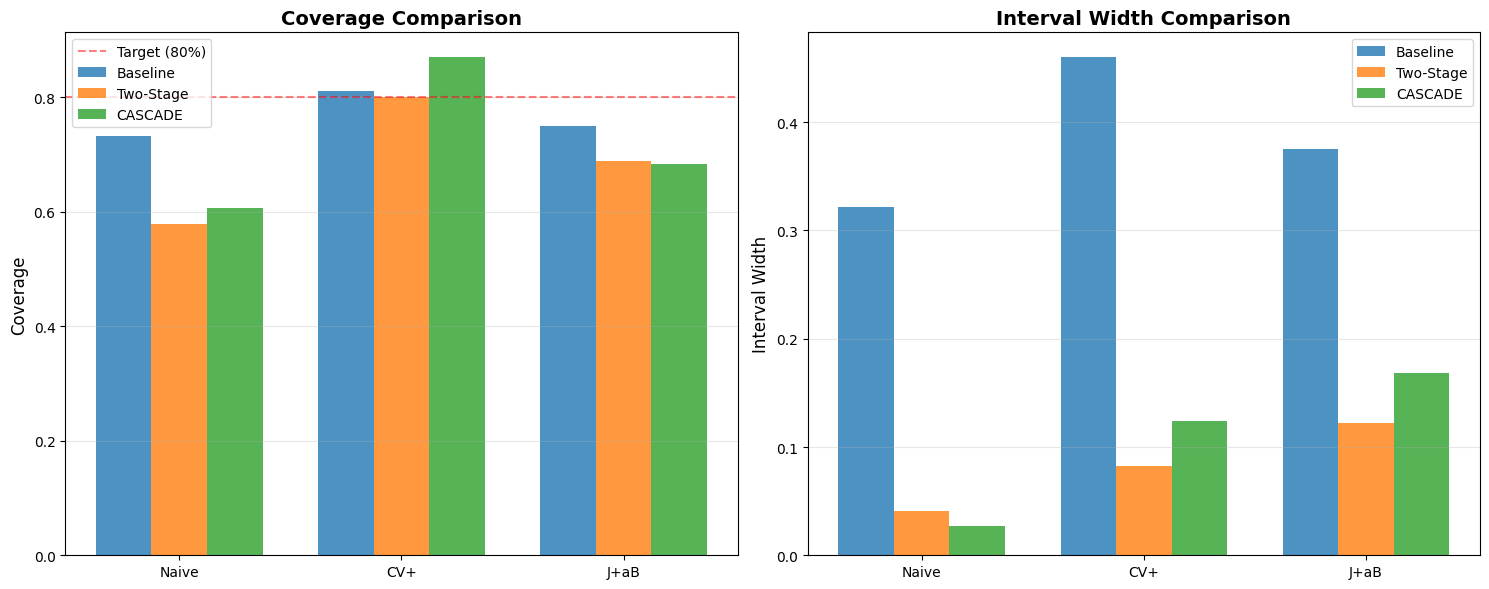

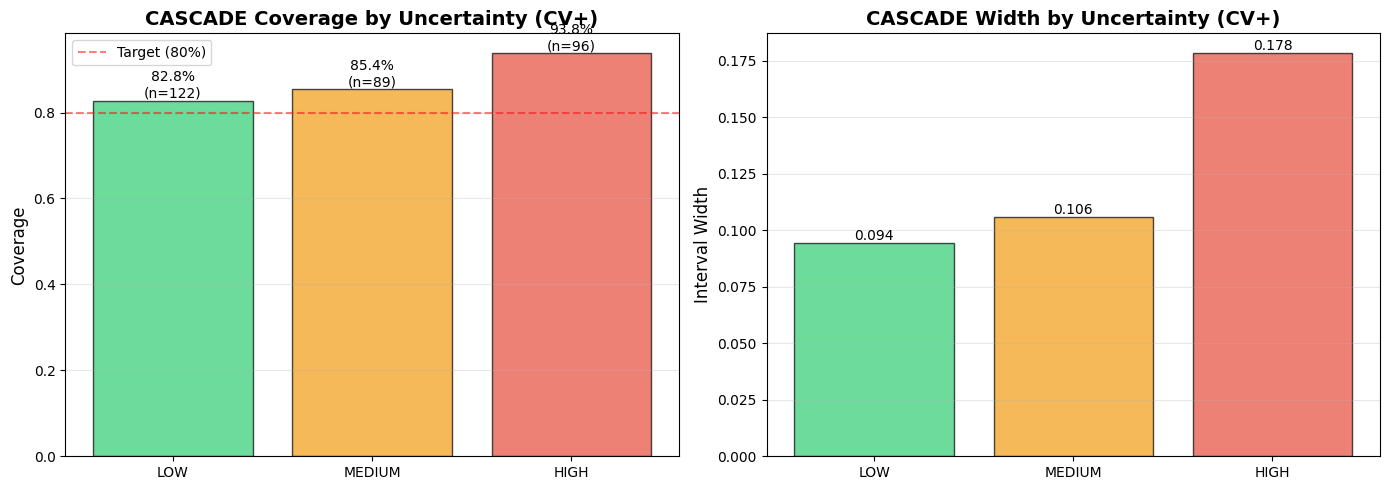

In [26]:
# Figure 1: Coverage and Width Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

x = np.arange(len(methods))
width = 0.25

baseline_covs = [baseline_1y[m]['coverage'] for m in methods]
twostage_covs = [twostage_1y[m]['coverage'] for m in methods]
cascade_covs = [cascade_stats[m]['coverage'] for m in methods]

ax1.bar(x - width, baseline_covs, width, label='Baseline', alpha=0.8)
ax1.bar(x, twostage_covs, width, label='Two-Stage', alpha=0.8)
ax1.bar(x + width, cascade_covs, width, label='CASCADE', alpha=0.8)
ax1.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Target (80%)')
ax1.set_ylabel('Coverage', fontsize=12)
ax1.set_title('Coverage Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([method_names[m] for m in methods])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

baseline_widths = [baseline_1y[m]['width'] for m in methods]
twostage_widths = [twostage_1y[m]['width'] for m in methods]
cascade_widths = [cascade_stats[m]['width'] for m in methods]

ax2.bar(x - width, baseline_widths, width, label='Baseline', alpha=0.8)
ax2.bar(x, twostage_widths, width, label='Two-Stage', alpha=0.8)
ax2.bar(x + width, cascade_widths, width, label='CASCADE', alpha=0.8)
ax2.set_ylabel('Interval Width', fontsize=12)
ax2.set_title('Interval Width Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([method_names[m] for m in methods])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Figure 2: CASCADE Stratification (CV+ only)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins_ordered = ['low', 'medium', 'high']
coverages = [np.mean(stratified['cv_plus']['coverage'][bins_test == b]) for b in bins_ordered]
widths = [np.mean(stratified['cv_plus']['width'][bins_test == b]) for b in bins_ordered]
counts = [np.sum(bins_test == b) for b in bins_ordered]

colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars1 = axes[0].bar(range(3), coverages, color=colors, alpha=0.7, edgecolor='black')
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Target (80%)')
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(['LOW', 'MEDIUM', 'HIGH'])
axes[0].set_ylabel('Coverage', fontsize=12)
axes[0].set_title('CASCADE Coverage by Uncertainty (CV+)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

for bar, cov, n in zip(bars1, coverages, counts):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{cov:.1%}\n(n={n})',
                ha='center', va='bottom', fontsize=10)

bars2 = axes[1].bar(range(3), widths, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(['LOW', 'MEDIUM', 'HIGH'])
axes[1].set_ylabel('Interval Width', fontsize=12)
axes[1].set_title('CASCADE Width by Uncertainty (CV+)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for bar, w in zip(bars2, widths):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{w:.3f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()